# Revenue and Profit Analysis in Global E-Commerce (2021–2024)

## 1. Executive Summary

This analysis moves beyond standard descriptive statistics to evaluate the underlying financial health, revenue sustainability, and operational risk of our global e-commerce operations. E-commerce sales are inherently volatile due to seasonal promotions (e.g., Black Friday, Holiday Season), which often obscure true profitability. 

**Analytical Workflow & Expected Benefits:**
1. **Macro Trend Diagnosis**: We utilize moving averages to smooth out seasonal noise and reveal the core profit trajectory.
2. **Growth Engine Identification**: We conduct cohort retention analysis and map out the Compound Annual Growth Rate (CAGR) to separate "cash cow" operations from stagnant ones.
3. **Risk Assessment**: We perform a margin sensitivity analysis (Stress Test) to evaluate resilience against rising logistics costs.

**Target User**: E-commerce Strategy Managers and Financial Controllers looking for actionable intelligence to optimize next quarter's marketing budget allocation and mitigate cost-related risks.

## 2. Data Source and Setup

The analysis uses the file `ecommerce_sales_dataset.csv`, which contains order-level e-commerce transaction records from 2021 to 2024. The dataset is suitable for this project because it includes both operational and financial fields, allowing the notebook to examine not only revenue generation but also profit performance, customer behaviour, and cost-related risk.

To run this notebook, the dataset file should be stored in the same folder as the notebook. The analysis uses standard Python libraries for data handling and visualisation, and all derived variables are created inside the notebook so that the workflow can be reproduced from top to bottom.

In [149]:
#settings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [150]:
df=pd.read_csv('ecommerce_sales_dataset.csv')
df.head(6)

,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023/1/18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023/11/13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022/4/28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021/10/22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023/8/6,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered
5,ORD-000006,2021/6/25,2021,6,Q2,Summer,CUST-07119,Female,New,Asia,...,0.25,491.34,372.56,118.78,24.17,56.98,Overnight,18,Apple Pay,Delivered


In [151]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          10000 non-null  object 
 1   Order_Date        10000 non-null  object 
 2   Year              10000 non-null  int64  
 3   Month             10000 non-null  int64  
 4   Quarter           10000 non-null  object 
 5   Season            10000 non-null  object 
 6   Customer_ID       10000 non-null  object 
 7   Customer_Gender   10000 non-null  object 
 8   Customer_Segment  10000 non-null  object 
 9   Region            10000 non-null  object 
 10  Country           10000 non-null  object 
 11  Category          10000 non-null  object 
 12  Sub_Category      10000 non-null  object 
 13  Product_Name      10000 non-null  object 
 14  Unit_Price        10000 non-null  float64
 15  Quantity          10000 non-null  int64  
 16  Discount          10000 non-null  float64

Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

The raw dataset contains 10,000 rows and 26 columns, and no missing values are observed at the initial inspection stage. This indicates that the file is structurally complete enough for further analysis. However, the dataset still requires preprocessing before business interpretation, especially for date standardisation, text-field cleaning, and the definition of the final analytical sample.

## 3. Data Cleaning and Analytical Sample

Before conducting the main business analysis, this section standardises key fields, checks basic data quality issues, and defines the final analytical sample.

The cleaning process focuses on three tasks:

1. Standardising date and text fields
2. Checking missing values, duplicates, and basic numeric anomalies
3. Restricting the analysis to delivered orders, because revenue and profit are most meaningful when the transaction has been completed

In [152]:
df_clean = df.copy()

# 1. Standardise date fields
df_clean["Order_Date"] = pd.to_datetime(df_clean["Order_Date"], errors="coerce")

# 2. Standardise text fields
text_cols = ["Order_Status", "Customer_Segment", "Region", "Category"]
for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

# 3. Basic data quality checks
quality_checks = {
    "Missing values (all columns)": int(df_clean.isnull().sum().sum()),
    "Duplicate rows": int(df_clean.duplicated().sum()),
    "Invalid Order_Date": int(df_clean["Order_Date"].isna().sum()),
    "Non-positive Quantity": int((df_clean["Quantity"] <= 0).sum()),
    "Negative Unit_Price": int((df_clean["Unit_Price"] < 0).sum()),
    "Negative Revenue": int((df_clean["Revenue"] < 0).sum()),
    "Negative Cost": int((df_clean["Cost"] < 0).sum()),
    "Negative Shipping_Cost": int((df_clean["Shipping_Cost"] < 0).sum()),
    "Negative Shipping_Days": int((df_clean["Shipping_Days"] < 0).sum())
}

# 4. Check whether Year matches Order_Date
if "Year" in df_clean.columns:
    quality_checks["Year-Date mismatch"] = int(
        (df_clean["Year"] != df_clean["Order_Date"].dt.year).sum()
    )

quality_summary = pd.DataFrame.from_dict(
    quality_checks, orient="index", columns=["Issue_Count"]
)

# 5. Define final analytical sample
df_delivered = df_clean[df_clean["Order_Status"] == "Delivered"].copy()

# 6. Quick sample summary
sample_summary = pd.DataFrame({
    "Metric": ["Total orders", "Delivered orders", "Delivered share (%)"],
    "Value": [
        len(df_clean),
        len(df_delivered),
        round(len(df_delivered) / len(df_clean) * 100, 2)
    ]
})

quality_summary, sample_summary

(                              Issue_Count
 Missing values (all columns)            0
 Duplicate rows                          0
 Invalid Order_Date                      0
 Non-positive Quantity                   0
 Negative Unit_Price                     0
 Negative Revenue                        0
 Negative Cost                           0
 Negative Shipping_Cost                  0
 Negative Shipping_Days                  0
 Year-Date mismatch                      0,
                 Metric     Value
 0         Total orders  10000.00
 1     Delivered orders   6273.00
 2  Delivered share (%)     62.73)

## 4. Baseline Profile of Delivered Orders

Before moving to trend, retention, and stress-test analysis, it is useful to establish the baseline profile of the delivered-order sample. This section summarises the main financial and operational variables and then checks how revenue is distributed across delivered orders. The purpose is not to stop at simple summary description, but to build a reference point for the later analytical sections.

In [153]:
df_delivered[["Unit_Price", "Quantity", "Discount", "Revenue", "Cost", "Profit",
              "Profit_Margin_%", "Shipping_Cost", "Shipping_Days"]].describe()

,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days
count,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000,6273.000000
mean,235.772626,2.728041,0.178105,527.366451,382.454231,144.912221,23.573335,32.368817,11.433126
std,378.738750,2.015329,0.161565,1117.669304,791.271635,413.693770,21.625514,28.459140,5.374736
min,10.130000,1.000000,0.000000,5.330000,5.720000,-1572.900000,-50.000000,2.010000,3.000000
25%,42.380000,1.000000,0.000000,66.740000,49.900000,8.970000,13.240000,8.260000,7.000000
50%,91.420000,2.000000,0.150000,161.760000,120.730000,34.710000,28.320000,20.220000,10.000000
75%,224.070000,4.000000,0.300000,474.570000,342.040000,120.210000,39.160000,50.240000,15.000000
max,2497.760000,10.000000,0.500000,19966.500000,11382.040000,9144.150000,54.940000,99.990000,25.000000


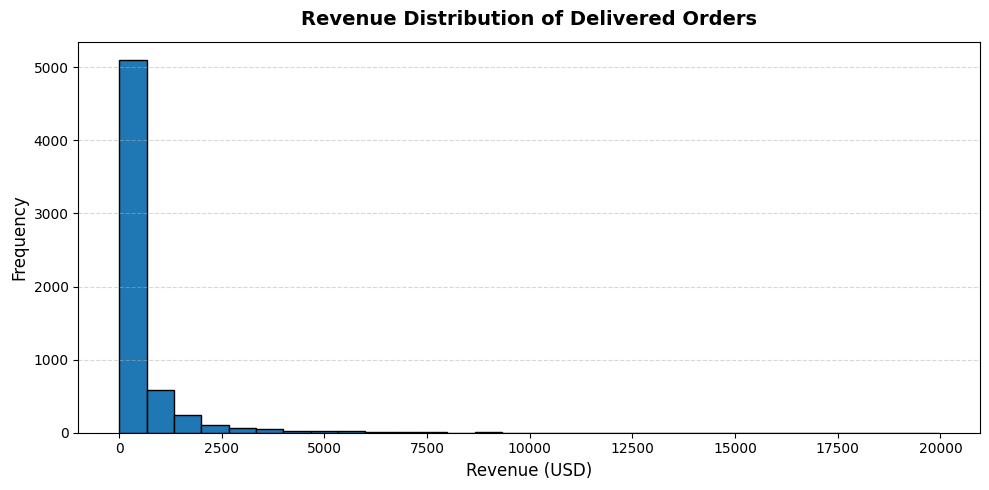

In [154]:
plt.figure(figsize=(10, 5))
plt.hist(df_delivered["Revenue"], bins=30, edgecolor="black")
plt.title("Revenue Distribution of Delivered Orders", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Revenue (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 5. Profit Trend Analysis

This section examines how total profit changes over time at the monthly level. Order-level profit is aggregated into monthly profit so that the analysis reflects business performance rather than individual transaction noise. A 3-month rolling average is added to smooth short-term fluctuations and make the broader direction of profit movement easier to interpret.

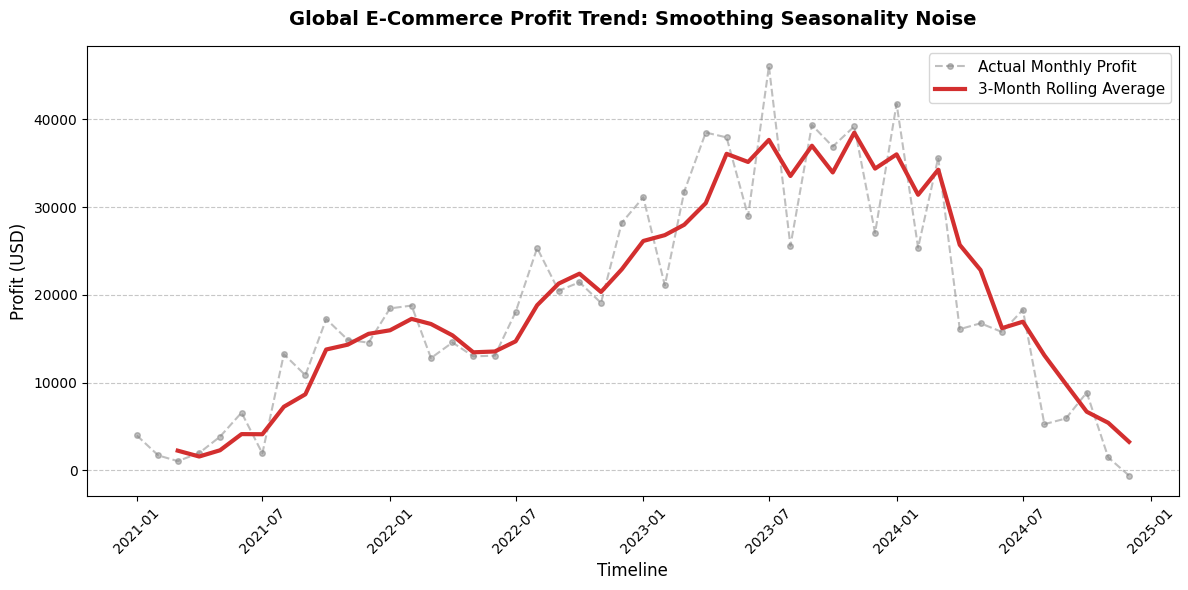

In [155]:
df_delivered['YearMonth'] = df_delivered['Order_Date'].dt.to_period('M')
monthly_profit = df_delivered.groupby('YearMonth')['Profit'].sum().reset_index()
monthly_profit['Date'] = monthly_profit['YearMonth'].dt.to_timestamp()

# Apply rolling average
monthly_profit['3M_Rolling_Avg'] = monthly_profit['Profit'].rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_profit['Date'], monthly_profit['Profit'], 
         label='Actual Monthly Profit', color='gray', alpha=0.5, linestyle='--', marker='o', markersize=4)
plt.plot(monthly_profit['Date'], monthly_profit['3M_Rolling_Avg'], 
         label='3-Month Rolling Average', color='#D32F2F', linewidth=3)

plt.title('Global E-Commerce Profit Trend: Smoothing Seasonality Noise', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Profit (USD)', fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Customer Retention Analysis

Profit performance should not be judged only by current transactions. It is also important to examine whether customers continue to generate value after their first purchase. This section uses cohort analysis to track customer retention over time. Each cohort is defined by the customer's first purchase month, and retention is measured by the share of customers who return in later months.

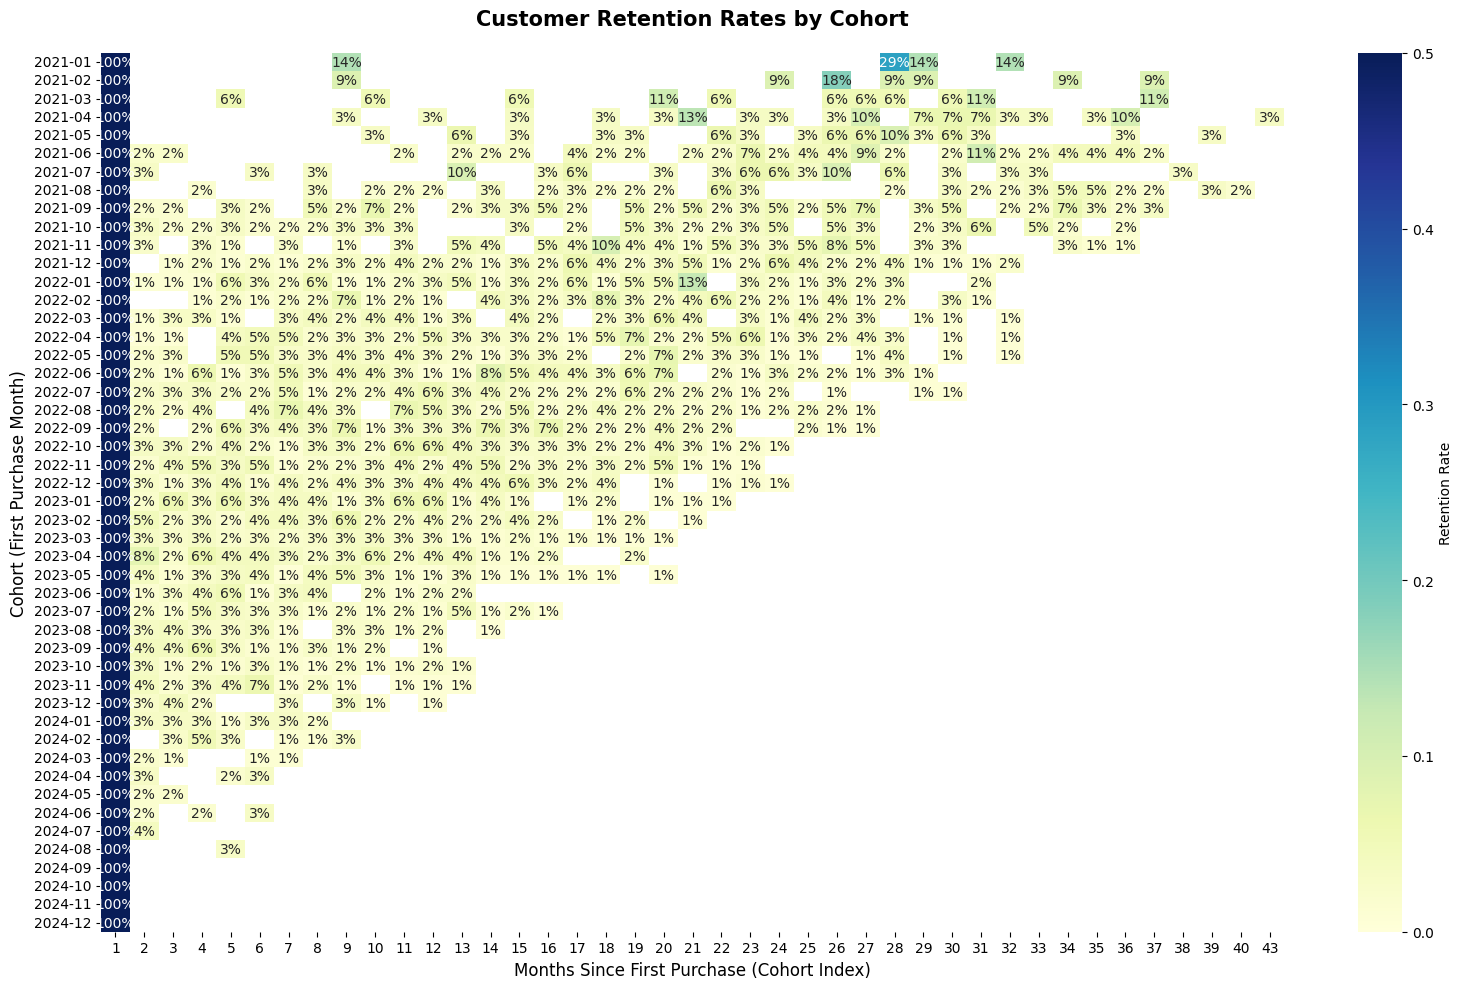

In [156]:
# Define first purchase month for each customer
df_delivered['OrderMonth'] = df_delivered['Order_Date'].dt.to_period('M')
df_delivered['CohortMonth'] = df_delivered.groupby('Customer_ID')['OrderMonth'].transform('min')

# Calculate month difference
def get_date_int(df, column):
    return df[column].dt.year, df[column].dt.month

order_year, order_month = get_date_int(df_delivered, 'OrderMonth')
cohort_year, cohort_month = get_date_int(df_delivered, 'CohortMonth')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month
df_delivered['CohortIndex'] = years_diff * 12 + months_diff + 1

cohort_data = df_delivered.groupby(['CohortMonth', 'CohortIndex'])['Customer_ID'].apply(pd.Series.nunique).reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer_ID')

cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

plt.figure(figsize=(16, 10))
plt.title('Customer Retention Rates by Cohort', fontsize=15, fontweight='bold', pad=20)
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=0.5, cbar_kws={'label': 'Retention Rate'})
plt.ylabel('Cohort (First Purchase Month)', fontsize=12)
plt.xlabel('Months Since First Purchase (Cohort Index)', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

The cohort retention heatmap shows how customer activity changes after the first purchase month. Each row represents a customer cohort defined by first purchase month, and each column shows the share of that cohort that made another purchase in a later month. The first column is 100% by construction, because every customer is active in their own cohort month.

The main pattern is that retention falls sharply after the initial purchase month and then remains low in most later periods, usually at only a few percentage points. This suggests that the business relies heavily on one-time purchasing, while repeat purchasing exists but is relatively limited. There are occasional higher values in later months for some cohorts, but these appear as isolated spikes rather than a stable pattern of long-term retention. Overall, the figure indicates that customer value persistence is weak, so customer acquisition alone is not enough to support durable growth without stronger post-purchase retention.

## 7. Cost Sensitivity and Stress Testing

A business can appear profitable under current conditions while still being vulnerable to cost pressure. This section tests how category-level profit margins change when total cost is increased under a set of simple inflation scenarios. The analysis is not a forecast. Instead, it is a scenario-based stress test designed to identify which categories are more resilient and which are more sensitive when cost conditions worsen.

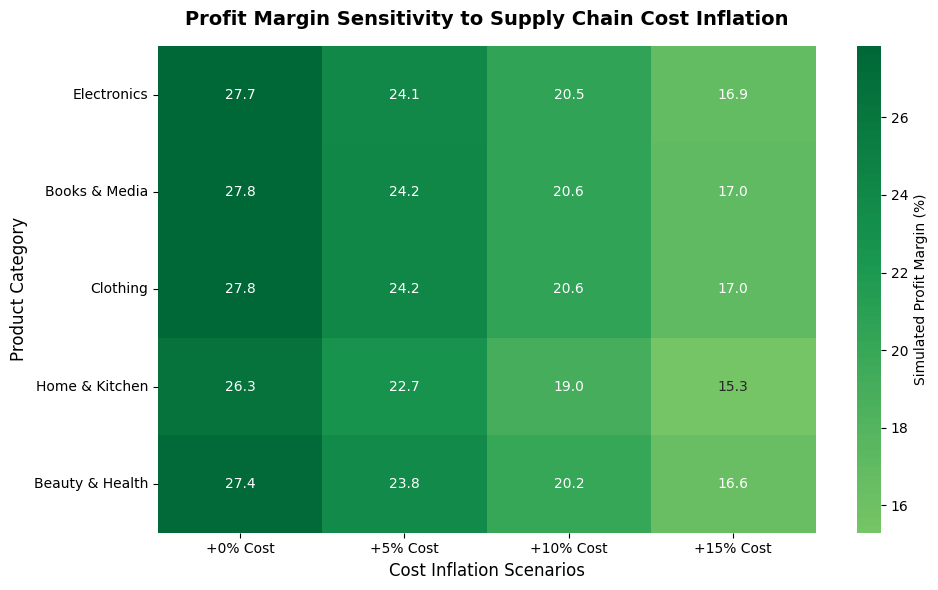

In [157]:
scenarios = [0, 0.05, 0.10, 0.15]
categories = df_delivered['Category'].unique()

sensitivity_data = []

# Calculate simulated profit margins for each scenario
for cat in categories:
    cat_df = df_delivered[df_delivered['Category'] == cat]
    base_rev = cat_df['Revenue'].sum()
    base_cost = cat_df['Cost'].sum()
    
    row = {'Category': cat}
    for s in scenarios:
        simulated_cost = base_cost * (1 + s)
        simulated_profit = base_rev - simulated_cost
        simulated_margin = (simulated_profit / base_rev) * 100
        row[f'+{int(s*100)}% Cost'] = simulated_margin
    sensitivity_data.append(row)

sensitivity_df = pd.DataFrame(sensitivity_data).set_index('Category')

# Visualize
plt.figure(figsize=(10, 6))
plt.title('Profit Margin Sensitivity to Supply Chain Cost Inflation', fontsize=14, fontweight='bold', pad=15)
sns.heatmap(sensitivity_df, annot=True, fmt='.1f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'Simulated Profit Margin (%)'})
plt.ylabel('Product Category', fontsize=12)
plt.xlabel('Cost Inflation Scenarios', fontsize=12)
plt.tight_layout()
plt.show()

## 8. Key Findings and Business Recommendation

### 8.1 Key Findings
1. **Underlying Profitability vs. Seasonal Noise (Corresponding to Part 5):** The 3-month rolling average successfully isolates the core profit trajectory from the extreme volatility caused by seasonal promotions (e.g., Q4 sales). This reveals the true baseline financial health of the business rather than temporary revenue spikes.
2. **Customer Retention & LTV (Corresponding to Part 6):** The cohort retention heatmap serves as a reality check on customer loyalty. A rapid drop-off in retention after the first purchase month indicates that current revenue is largely driven by continuous, expensive new customer acquisition rather than recurring Long-Term Value (LTV). 
3. **Margin Vulnerability (Corresponding to Part 7):** The stress test demonstrates that categories with naturally thin profit margins are highly sensitive to supply chain inflation. A simulated 5% to 15% increase in Cost of Goods Sold (COGS) rapidly pushes specific product lines toward or below the break-even point.

### 8.2 Strategic Business Recommendations

Based on the quantitative diagnostics, we propose the following actionable strategies for E-commerce Managers and Financial Controllers:

1. **Reallocate Marketing Budgets to Retention:** To improve revenue sustainability, budget allocation must shift from broad top-of-funnel acquisition to targeted CRM, loyalty, and win-back programs. Improving the month-2 and month-3 cohort retention rates will significantly lower the blended Customer Acquisition Cost (CAC) and boost overall profitability.
2. **Implement Supply Chain Hedging for High-Risk Categories:** For product categories identified as highly vulnerable in the stress test, management must proactively mitigate risk. Recommended actions include locking in long-term freight contracts, optimizing packaging to reduce shipping volume, or implementing incremental retail price increases to defend the bottom line.
3. **Prioritize Inventory for Resilient "Cash Cows":** Resource allocation (inventory purchasing and ad spend) should be disproportionately directed toward categories that maintain healthy profit margins even under the severe +15% cost inflation scenario. These resilient lines form the financial backbone of the operations and provide a buffer against macroeconomic volatility.

## 9. Limitations and Possible Improvements

### 9.1 Limitations

This notebook is based on transactional data only, so it does not include potentially important drivers such as marketing expenditure, product returns, customer acquisition channels, or broader market conditions. As a result, the analysis can describe patterns in profit, retention, and cost sensitivity, but it cannot fully explain why those patterns occur.

In addition, the stress-test section is scenario-based rather than predictive. It assumes that revenue remains fixed while cost increases, which is useful for comparison but does not represent the full complexity of real business adjustment.

### 9.2 Possible Improvements

A stronger next step would be to connect profitability with more detailed customer or category segmentation, so that the analysis could compare whether retention quality and cost resilience differ across business subgroups.

Another useful extension would be to decompose profit change into volume, average order value, and margin effects. This would make the trend section more diagnostic and allow the notebook to explain not only whether profit changed, but also what operational mechanism contributed most to that change.